# Análise Exploratória de Dados (EDA)

Este notebook tem como objetivo realizar a análise exploratória do conjunto de
dados de diabetes, buscando compreender a estrutura dos dados, a distribuição
das variáveis, o balanceamento da variável alvo e possíveis inconsistências que
impactam a modelagem.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Preparação do Ambiente

Nesta seção importamos as bibliotecas usadas ao longo do EDA. O foco é:
- manipulação de dados (`pandas`, `numpy`)
- visualização (`matplotlib`, `seaborn`)

A partir daqui, todos os gráficos e tabelas serão gerados com essas dependências.


## Carregamento do Dataset

Nesta etapa, o dataset é carregado e inspecionado para compreender sua estrutura
inicial, número de registros e tipos das variáveis.


In [4]:
df = pd.read_csv("../data/raw/diabetes.csv")

### Visão geral do dataset

Após carregar o CSV, fazemos uma inspeção rápida para entender:
- as primeiras linhas (sanidade do carregamento)
- tipos das colunas e possíveis `null`s
- estatísticas descritivas (média, desvio, quartis)


In [5]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Distribuição da Variável Alvo

Análise do balanceamento entre pacientes com e sem diagnóstico de diabetes,
avaliando a necessidade de métricas específicas durante a modelagem.


In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

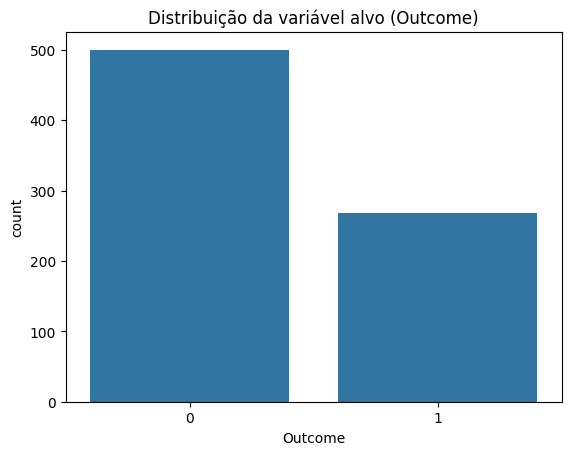

In [7]:
sns.countplot(x="Outcome", data=df)
plt.title("Distribuição da variável alvo (Outcome)")
plt.show()


### Comparação de variáveis por classe

Além do balanceamento, é útil comparar as variáveis entre as classes (Outcome 0 vs 1) para ter uma primeira noção de separabilidade.

Aqui começamos pela comparação de médias (visão agregada) e em seguida olhamos uma variável individual com boxplot.


In [8]:
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


### Exemplo com uma variável: `Glucose`

O boxplot ajuda a visualizar:
- diferença de mediana entre classes
- dispersão (IQR)
- presença de outliers

Em geral, espera-se que glicose tenha um bom poder discriminativo para diabetes.


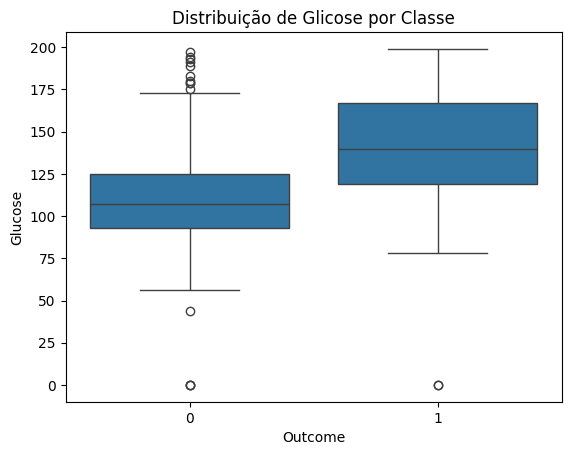

In [9]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Distribuição de Glicose por Classe")
plt.show()

## Checagem de inconsistências (zeros que indicam ausência)

Neste dataset, algumas variáveis biométricas não deveriam ser **zero** em condições normais (por exemplo, `Glucose`, `BMI`).

Valores 0 nesses campos costumam representar *missing values* codificados como zero, então aqui contamos quantos zeros aparecem por coluna para orientar o pré-processamento.


In [10]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

(df[cols_with_zero] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

## Distribuição das variáveis (visão univariada)

Histogramas permitem avaliar:
- assimetria e caudas longas
- possíveis outliers
- necessidade de transformações/normalização

A leitura aqui é exploratória; o tratamento em si fica para a etapa de pré-processamento.


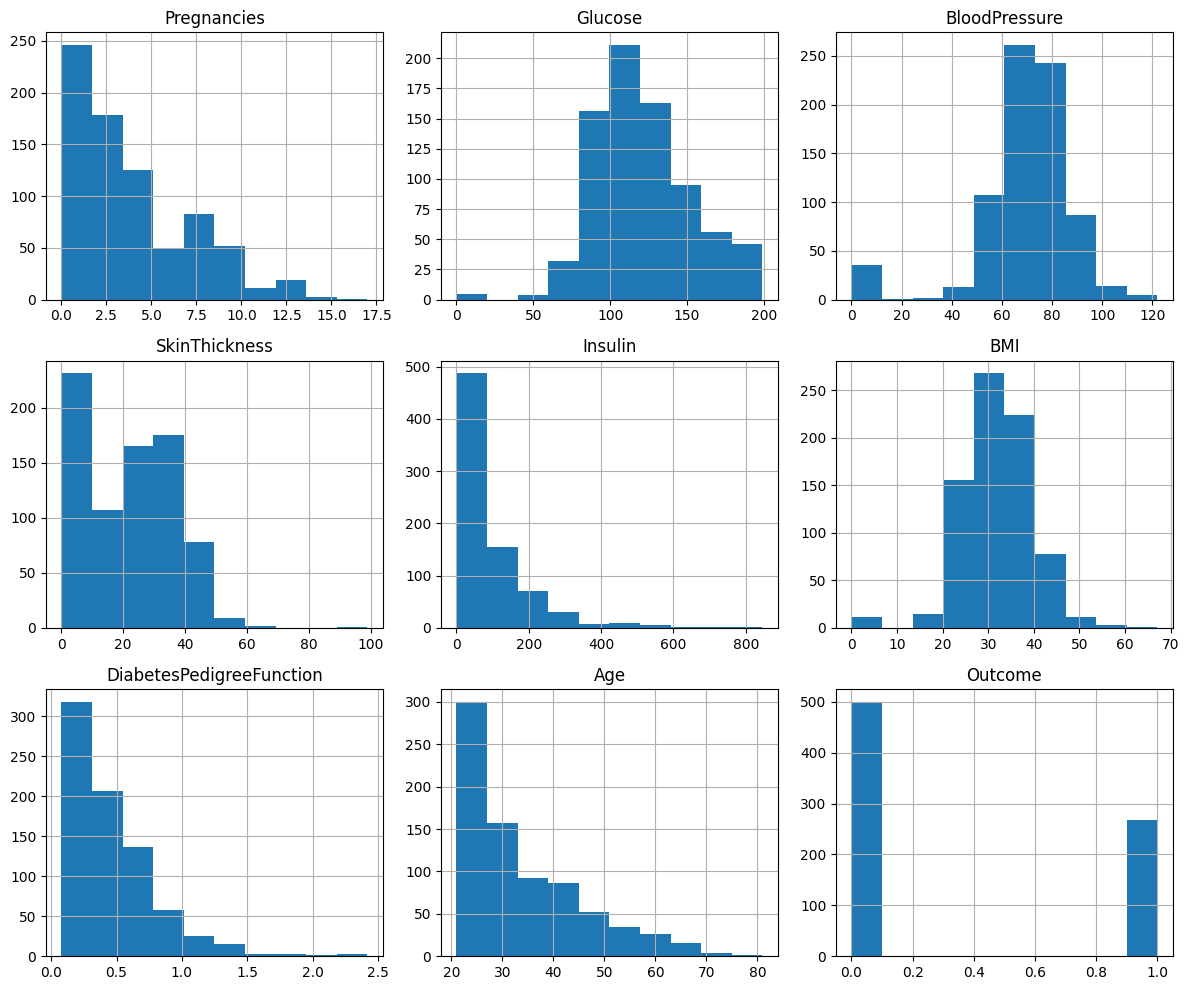

In [11]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


## Relações entre variáveis (correlação)

A matriz de correlação (Pearson) dá uma visão rápida de colinearidade entre features e de quais variáveis tendem a se mover juntas.

Observação: como `Outcome` é binária, a correlação com ela pode ser interpretada como um sinal inicial de associação linear, mas não substitui avaliação de modelo.


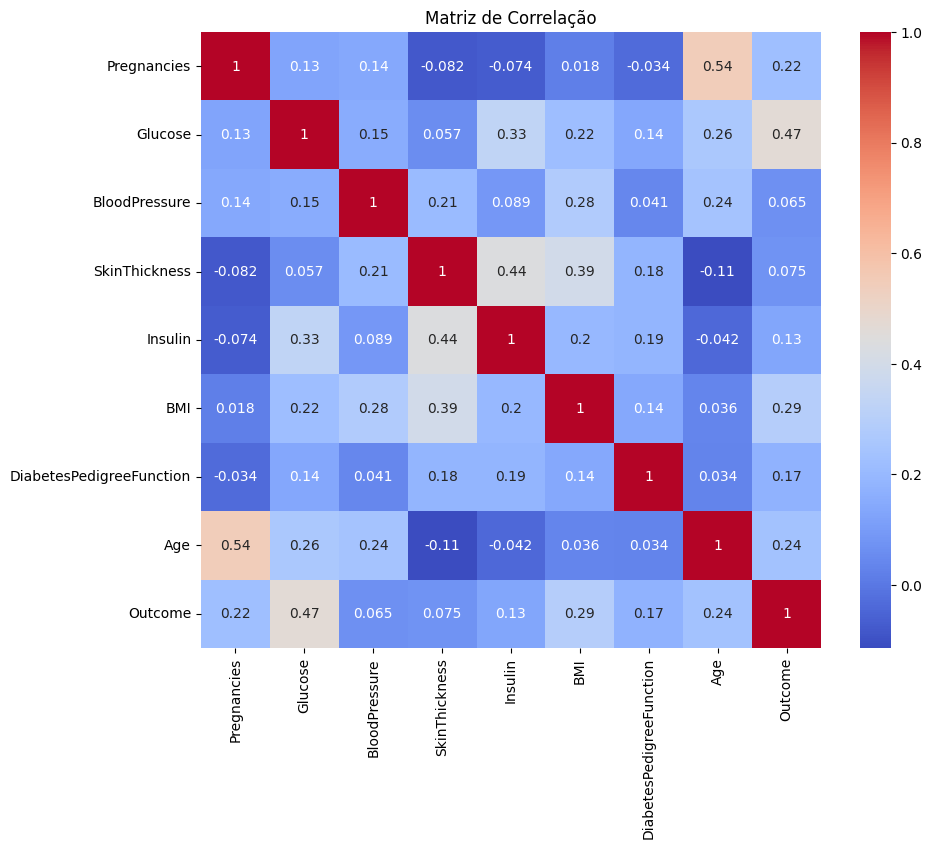

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()


## Conclusões da Análise Exploratória

- O dataset apresenta dados inconsistentes que exigem tratamento.
- Variáveis como glicose e IMC mostram forte relação com o diagnóstico.
- Há necessidade de normalização devido a escalas distintas.
